<a href="https://colab.research.google.com/github/matiGitH/Pokemon-Exploratory-Data-Analysis/blob/main/Pokemon_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Preparation

### Import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Import and Convert csv Files to DataFrames

We will be performing EDA with the information provided by 2 csv files.

The first one, "pokemon.csv" contains general information on all 802 pokemons that we will be exploring.

The second one, "type_effectiveness_chart.csv" contains all the damage relationships between attackers and defenders of all pokemon types

In [4]:
# read pokemon.csv as DataFrame
df = pd.read_csv("../data/pokemon.csv")

# Read type_effectiveness_chart.csv as DataFrame
df_types = pd.read_csv("../data/type_effectiveness_chart.csv", index_col=0)

### Visualize Dataframe

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   abilities          801 non-null    object 
 1   against_bug        801 non-null    float64
 2   against_dark       801 non-null    float64
 3   against_dragon     801 non-null    float64
 4   against_electric   801 non-null    float64
 5   against_fairy      801 non-null    float64
 6   against_fight      801 non-null    float64
 7   against_fire       801 non-null    float64
 8   against_flying     801 non-null    float64
 9   against_ghost      801 non-null    float64
 10  against_grass      801 non-null    float64
 11  against_ground     801 non-null    float64
 12  against_ice        801 non-null    float64
 13  against_normal     801 non-null    float64
 14  against_poison     801 non-null    float64
 15  against_psychic    801 non-null    float64
 16  against_rock       801 non

### Drop Irrelevant Columns

In [6]:
df.drop(labels=["japanese_name", "percentage_male", "classfication", "pokedex_number", "abilities", "base_happiness"], axis=1, inplace=True)

### Global Variables

In [7]:
TYPES = df["type1"].unique()
TYPES_INDEX = ["HP", "Attack", "Defense", "Speed", "Special Attack", "Special Defense"]

## Which Pokémon types are predominant?

As dual types are part of two groups, each will contribute to both.

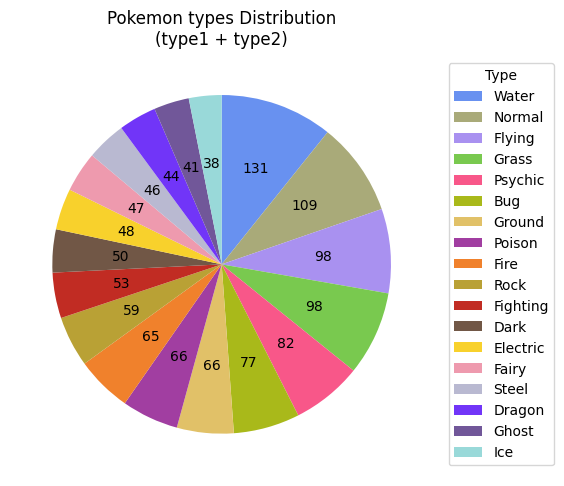

In [8]:
types_distribution = pd.concat(
    [df["type1"], df["type2"]],
    ignore_index=True
).value_counts()

total = types_distribution.sum()

plt.figure(figsize=(6, 5))

plt.subplots_adjust(right=0.75)


wedges, _, autotexts = plt.pie(
    types_distribution,
    startangle=90,
    radius=1,
    counterclock=False,
    autopct=lambda pct: f"{int(round(pct * total / 100.0))}",
    colors=[
        '#6891f0', '#a9aa79', '#a991f0', '#79c94f', '#f85789',
        '#a9b91a', '#e1c168', '#a13ea1', '#f0812c', '#b9a135',
        '#c12c23', '#715746', '#f8d12c', '#ee9aae', '#b9b9d1',
        '#7135f8', '#715799', '#99d9d9'
    ]
)

plt.legend(
    wedges,
    [t.capitalize() for t in types_distribution.index],
    title="Type",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.title("Pokemon types Distribution\n(type1 + type2)")
plt.tight_layout()
plt.show()



In this graph we can clearly observe the type distribution, with a clear majority of water type pokemons.

As a big part of pokemons are dual type, we made them count for both types. For that reason, the numbers do not add up to 802.

## Pokémon Stats

All Pokémon are defined by six core stats that determine their performance in battle:

+ HP: determines how much damage a Pokémon can take before fainting
+ Attack: influences the damage dealt by physical moves
+ Defense: reduces damage received from physical attacks
+ Special Attack: influences the damage dealt by special moves
+ Special Defense: reduces damage received from special attacks
+ Speed: determines which Pokémon acts first

### Which stats have the highest and lowest averages?

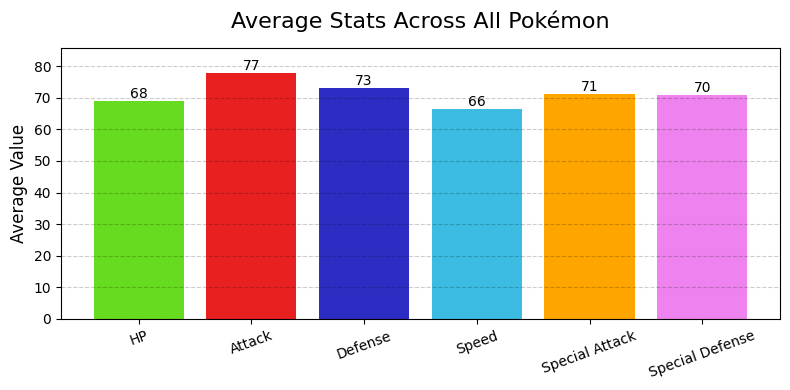

In [9]:
stat_means = df[["hp", "attack", "defense", "speed", "sp_attack", "sp_defense"]].mean()

plt.figure(figsize=(8,4))

bars = plt.bar(TYPES_INDEX, stat_means, color=["#67db1f", "#e82020", "#2d2dc4", "#3dbce3", "orange", "violet"])

plt.title("Average Stats Across All Pokémon", fontsize=16, pad=15)
plt.ylabel("Average Value", fontsize=12)

# Styles
plt.xticks(rotation=20)
plt.margins(y=0.1)
plt.grid(axis='y', linestyle='--', alpha=0.2, color="black")

# See values over each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{int(height)}',
             ha='center',
             va='bottom',
             fontsize=10)

plt.tight_layout()
plt.show()

We can observe that Pokémon stats are fairly evenly distributed across all Pokémon, with slightly higher totals in Attack and Defense at the expense of HP and Speed.

### Do certain Pokémon types excel in specific stats?

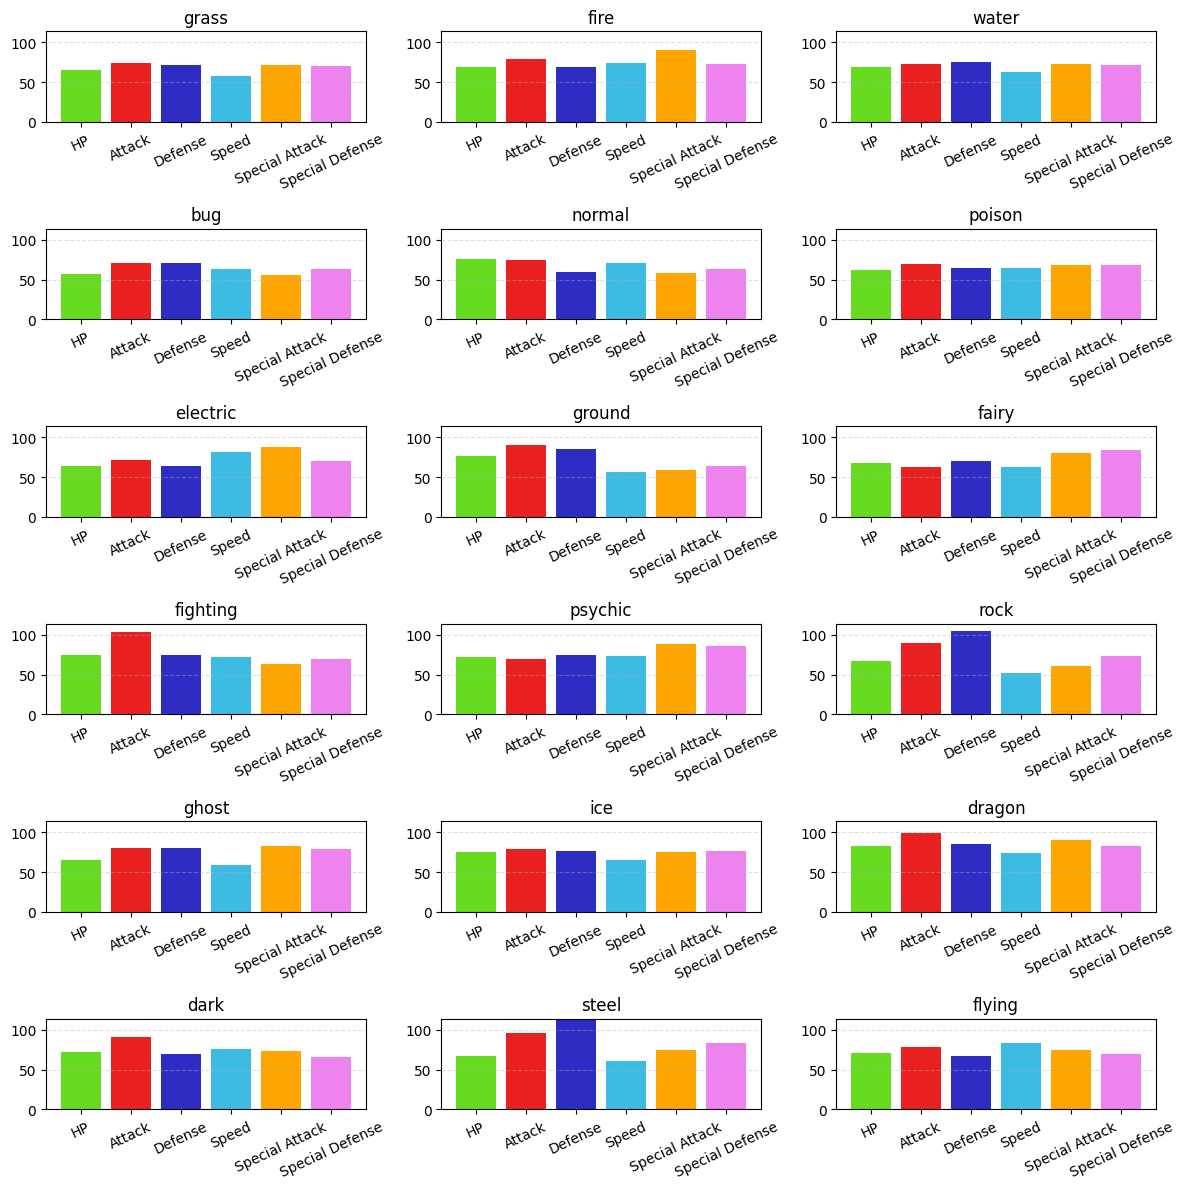

In [10]:
global_max = 0

for t in TYPES:
    subset = df[(df["type1"] == t) | (df["type2"] == t)]
    stat_sums = subset[
        ["hp", "attack", "defense", "speed", "sp_attack", "sp_defense"]
    ].mean()

    global_max = max(global_max, stat_sums.max())

fig, ax = plt.subplots(6, 3, figsize=(12, 12))
ax = ax.flatten()

for i, t in enumerate(TYPES):

    subset = df[(df["type1"] == t) | (df["type2"] == t)]
    stat_sums = subset[
        ["hp", "attack", "defense", "speed", "sp_attack", "sp_defense"]
    ].mean()

    ax[i].bar(TYPES_INDEX, stat_sums, color=["#67db1f", "#e82020", "#2d2dc4", "#3dbce3", "orange", "violet"])
    ax[i].set_title(t)
    ax[i].tick_params(axis="x", rotation=25)
    ax[i].set_ylim(0, global_max)
    ax[i].grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

These graphs make it easy to see each Pokémon type's main strengths and weaknesses at a glance.

Overall, most types appear fairly balanced: Some Pokémon tend to be well-rounded across all stats, while others clearly sacrifice certain attributes in order to excel in others.

We can answer then that clear patterns do emerge. For example:

+ Electric types tend to have higher Speed and Special Attack, trading off bulk.
+ Ground types stand out with significantly higher HP, Attack, and Defense, but lag behind in Speed and special stats.
+ Fighting types are heavily skewed toward high Attack with otherwise balanced stats.
+ Rock and Steel types are strongly oriented toward Defense (and solid Attack), often sacrificing Speed in the process.

These trends suggest that stat distributions are not random, but instead reflect distinct strategic roles for each type.


### What is the strongest Pokémon Type?

Text(0, 0.5, 'Average Total Base Stats')

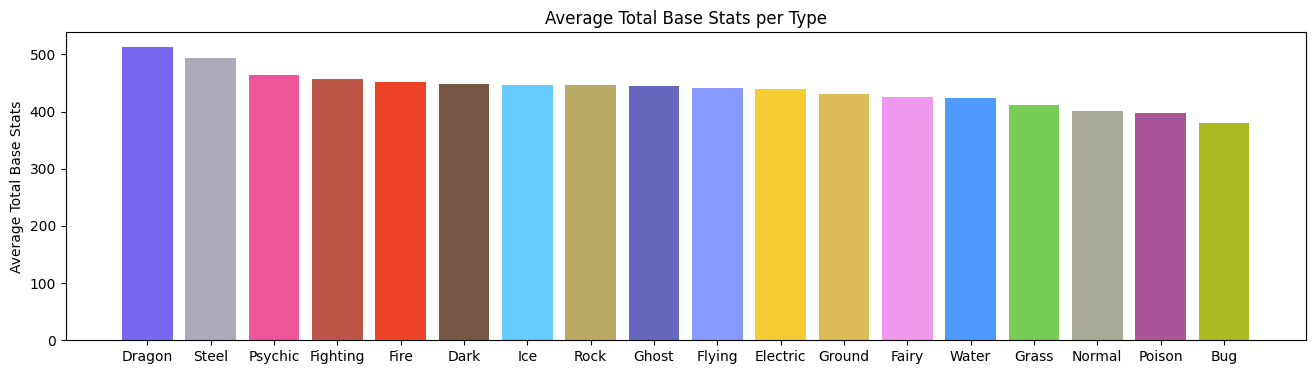

In [11]:
total_stats_per_type = pd.Series(dtype=float)

for t in TYPES:
    average = df.loc[(df["type1"] == t) | (df["type2"] == t),"base_total"].mean()

    total_stats_per_type[t] = average

total_stats_per_type = total_stats_per_type.sort_values(ascending=False)

plt.figure(figsize=(16,4))

types_cap = [t.capitalize() for t in total_stats_per_type.index]

plt.bar(types_cap, total_stats_per_type.values, color=["#7867ee", "#aaaabb", "#ee5499", "#bb5545",  "#ec4225", "#775544", "#66ccff", "#bbaa66", "#6667bc", "#8899ff", "#f5cc34", "#ddbb55", "#ee99ee", "#4e9aff", "#77cc55", "#aaaa99", "#aa5599", "#aabb22"])
plt.title("Average Total Base Stats per Type")
plt.ylabel("Average Total Base Stats")


We can conclude that the Pokémon Dragon Type are the strongest.

### Are Legendary Pokémon always stronger?

Legendary Pokémon are often considered far superior to regular ones — but is that assumption actually supported by data? Let's compare the total base stats distributions of Normal and Legendary Pokémon to find out.

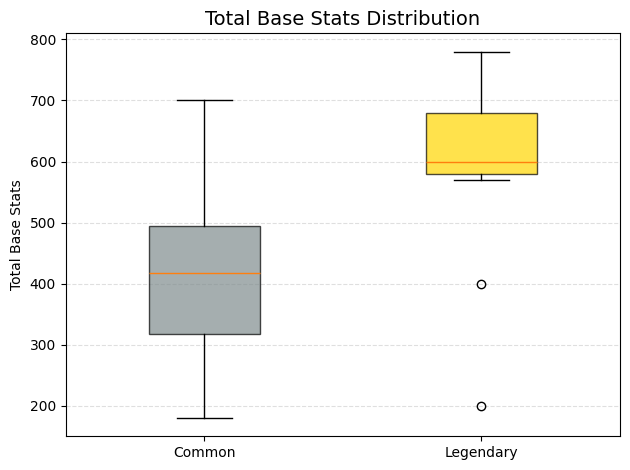

In [12]:
df_legendaries = df[df["is_legendary"] == 1]
df_commons = df[df["is_legendary"] == 0]

box = plt.boxplot(
    [df_commons["base_total"], df_legendaries["base_total"]],
    widths=0.4,
    patch_artist=True,
    showfliers=True,
    tick_labels=["Common", "Legendary"]
)
# Style
plt.title("Total Base Stats Distribution", fontsize=14)
plt.ylabel("Total Base Stats")

plt.grid(axis="y", linestyle="--", alpha=0.4)

# Add color
colors = ["#7f8c8d", "#FFD700"]

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.tight_layout()
plt.show()

Although Legendary Pokémon clearly have a much higher median total stat than Common ones, the distribution of Common Pokémon is far more variable. In fact, the strongest Common Pokémon reach values that overlap with the lower 75% of the Legendary distribution, meaning that not all Legendary Pokémon are stronger than common ones.

Fun Fact:

Those extreme outliers on the Legendary side correspond to Cosmog and Cosmoem—unusually weak compared to the rest.

## Have Pokémon Become Stronger Across Generations?

To answer this question, we will analyze the average total base stats of Pokémon introduced in each generation.

We will also explore a possible explanation by comparing these averages with the Legendary Pokémon rate per generation, that is, the percentage of Pokémon classified as Legendary in each generation.

Our hypothesis is that, since Legendary Pokémon typically have higher base stats, an increase in the proportion of Legendary Pokémon over time may have contributed to the overall rise in average Pokémon power across generations.

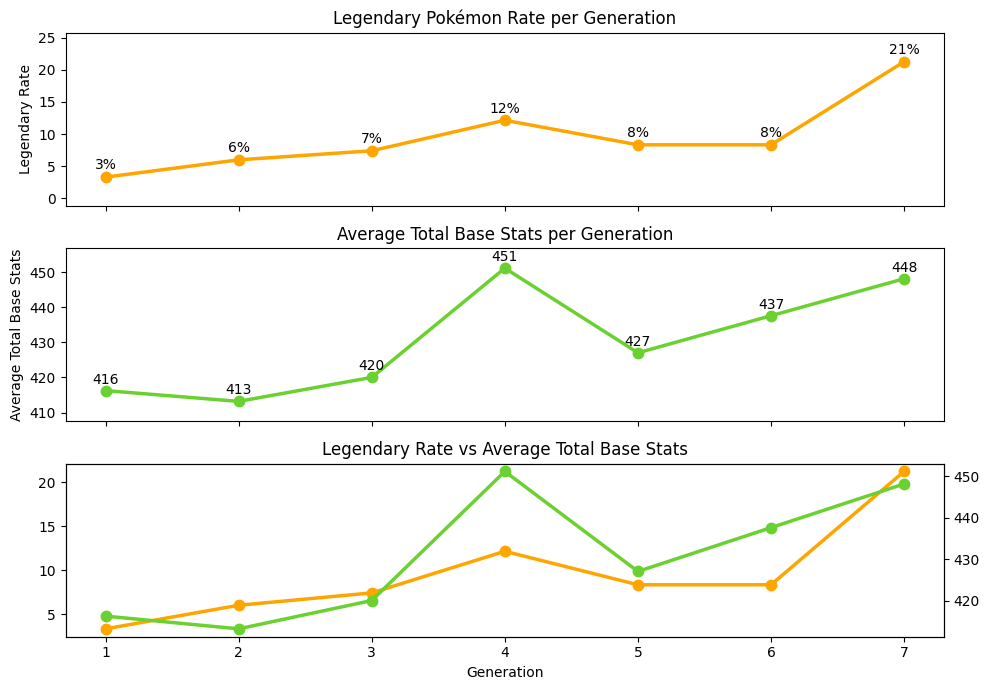

In [13]:
# Get data
legendary_per_gen = df.groupby("generation")["is_legendary"].sum()
total_per_gen = df.groupby("generation").size()

legendary_percentage = (legendary_per_gen / total_per_gen) * 100
avg_stats_per_gen = df.groupby("generation")["base_total"].mean()

fig, ax = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

# Plot 1: Legendary count
ax[0].plot(legendary_percentage.index, legendary_percentage.values,
           lw=2.5, color="orange", marker=".", ms=15)

for x, y in zip(legendary_percentage.index, legendary_percentage.values):
    ax[0].text(x, y + 1.2, str(int(y))+"%", ha='center')

ax[0].set_title("Legendary Pokémon Rate per Generation")
ax[0].set_ylabel("Legendary Rate")
# Leave some margin
ax[0].margins(y=0.25)


# Plot 2: Average base stats
ax[1].plot(avg_stats_per_gen.index, avg_stats_per_gen.values,
           lw=2.5, color="#6BD130", marker=".", ms=15)
ax[1].set_title("Average Total Base Stats per Generation")
ax[1].set_ylabel("Average Total Base Stats")
for x, y in zip(avg_stats_per_gen.index, avg_stats_per_gen.values):
    ax[1].text(x, y + 2, str(int(y)), ha='center')

# Leave some margin
ax[1].margins(y=0.15)

# Plot 3: Both with dual axis
ax3_left = ax[2]
ax3_right = ax3_left.twinx()

ax3_left.plot(legendary_percentage.index, legendary_percentage.values, lw=2.5, color="orange", marker=".", ms=15)

ax3_right.plot(avg_stats_per_gen.index, avg_stats_per_gen.values, lw=2.5, color="#6BD130", marker=".", ms=15)

ax[2].set_title("Legendary Rate vs Average Total Base Stats")
ax[2].set_xlabel("Generation")

plt.tight_layout()
plt.show()

Looking at both plots together, we can observe a clear and consistent pattern: an increase in the Legendary Pokémon Rate is strongly associated with higher average base stats within a generation. This is consistent with the clear difference in average stats observed in the Normal vs. Legendary Pokémon section.

## Are Heavier Pokémon More Powerful?

It seems intuitive to think that bigger Pokémon should be stronger. But does that idea hold true in the Pokémon universe?

To find out, we'll explore the relationship between a Pokémon's weight and its overall strength, measured by its total base stats.

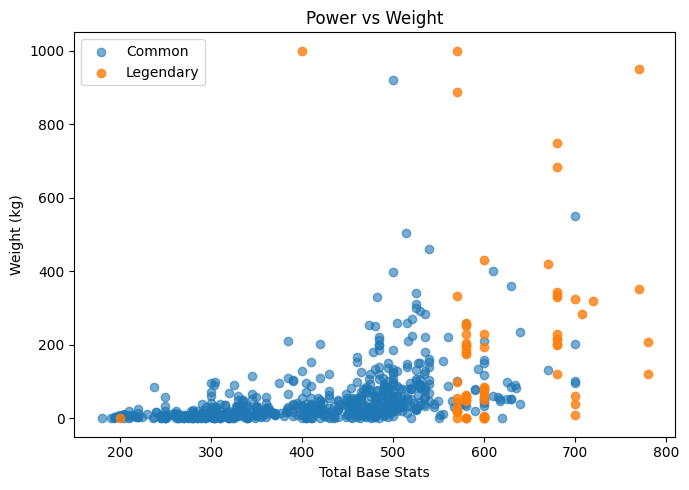

In [14]:
plt.figure(figsize=(7,5))

# Common
plt.scatter(
    df.loc[df["is_legendary"] == 0, "base_total"],
    df.loc[df["is_legendary"] == 0, "weight_kg"],
    alpha=0.6,
    label="Common"
)

# Legendary
plt.scatter(
    df.loc[df["is_legendary"] == 1, "base_total"],
    df.loc[df["is_legendary"] == 1, "weight_kg"],
    alpha=0.8,
    label="Legendary"
)

plt.xlabel("Total Base Stats")
plt.ylabel("Weight (kg)")
plt.title("Power vs Weight")

plt.legend()
plt.tight_layout()
plt.show()

The scatter plot reveals a mild positive association between total power and weight. However, the relationship is not symmetric:

*   Weak Pokémon are almost exclusively lightweight, with virtually no heavy individuals at low power levels.
*   As total base stats increase, the vertical dispersion expands, and weight becomes much more variable.
* Density decays as well as the overall number of Pokémon.






In other words, powerful Pokémon can be either light or heavy, but weak Pokémon are consistently light.

We also observe once again that Legendary Pokémon dominate the right side of the plot, as they tend to have higher stats.

In [15]:
correlation = df["base_total"].corr(df["weight_kg"])
print(f"Pearson correlation coefficient: {correlation:.2f}")

Pearson correlation coefficient: 0.46


The Pearson correlation coefficient backs up our analysis, with a possitive yet weak relationship between weight and total base stats.

## Which Is the Best Pokemon?


Evaluating Pokémon strengths is not a straightforward task. To approach this problem, we will use two methods:

1. A basic comparison based on Total Stats.
2. A composite score based on weighted factors, including Total Stats, defensive effectiveness, and offensive effectiveness.

### Based on Total Base Stats

In [16]:
df[["name", "base_total", "is_legendary"]].sort_values(by="base_total", ascending=False).head(3)

,name,base_total,is_legendary
149,Mewtwo,780,1
383,Rayquaza,780,1
381,Kyogre,770,1


Mewtwo and Rayquaza turn out to be the pokemons with the best stats. It is not surprising due to their legendary status.

### Based on Total Base Stats + Defensive Score + Offensive Score


In order to combine these three main factors, we have to asign a weight to each.

#### Total Base Stats (65%)


This one is the most important. It is not dependent on who your opponent is, as Defensive and Offensive Effectiveness, and sets a clear difference between more and less powerful pokemons.
It is easily calculated (the sum of all stats).

#### Defensive Score (25%)



Defensive effectiveness measures how much damage a Pokémon receives from different types.
Some types are more resistant (taking reduced damage), while others are more vulnerable, which can significantly impact battle performance.

To quantify this, we assign a score to each effectiveness level and sum them across all attacking types using the against_? columns in the dataset:

0.0 → +3 (immune)

0.25 → +2

0.5 → +1 (resistant)

1.0 → 0 (neutral)

2.0 → -1 (weak)

4.0 → -2 (very weak)

Higher scores indicate better overall defensive resilience.

In [17]:
against_cols = [col for col in df.columns if col.startswith("against_")]

df[against_cols] = pd.DataFrame(np.select(
    [df[against_cols] == 2.0, df[against_cols] == 0.5, df[against_cols] == 0.0],
    [-1, 1, 2],
    default=0))

# Create defensive score column for each pokemon
df["defensive_score"] = df[against_cols].sum(axis=1)

With this new column, we can now take a look at how strong each Pokémon type (and type combination) is defensively. Let's, for example, get the top 5 best deffensive types.

In [18]:
df[["type1", "type2", "defensive_score"]].sort_values(by="defensive_score", ascending=False).drop_duplicates(subset=["type1", "type2"]).head(5)

,type1,type2,defensive_score
624,dark,steel,11
302,steel,fairy,10
678,steel,ghost,10
597,grass,steel,9
80,electric,steel,9


We can see that, as is well known, Steel-type Pokémon are extremely strong defensively, and dual-type combinations tend to perform even better overall in terms of defensive effectiveness.

#### Offensive Score (10%)

It is built around the effectiveness type chart, given the pokemon type/s. We calculate the total score for the type/s using the same score table we used for defensive score, but this time looking at the effectiveness of the pokemon type's when attacking.

But, why do we concentrate in the pokemon type if a certain pokemon can use moves from other types, not necessarily theirs?

Well, there are two main reasons:
1. Taking into account each pokemon list of moves that can be learnt would be exhausting and not very rewarding. So, we assume any pokemon can perform any move from any type.

However, wouldn't that mean every pokemon has the same offensive effectiveness? No, because:

2. When a pokemon performs a move their own type, they deal a x1.5 damage due to the STAB mechanic. This makes a great difference, making attacking with their own type much more rewarding. This is the reason we give such importance to the effectiveness of those types in particular.


However, given that any pokemon can virtually perform any move from any type, this score is not as important.

Finally, we use the same score table from defensive score to assign the values, but we use df_types in order to calculate the effectiveness of each type. If a pokemon has 2 types, it always chooses the best attack type.

In [19]:
# change effectiveness for scores
df_types = pd.DataFrame(np.select([df_types == 2.0, df_types == 0.5, df_types == 0.0],
                            [1, -1, -2],
                            default=0),
                            index=df_types.index,
                            columns=df_types.columns)

# function that calculates offensive score for 1 pokemon
def pokemon_offensive_score(type1, type2=None):
    """
    Takes 2 parameters:
    1. type1: First pokemon type
    2. type2: Secondary pokemon type (optional)
    returns the offensive_score of that pokemon's type/s
    """
    if pd.notna(type2):
        df_new = df_types.loc[[type1, type2]]
        return df_new.max().sum()
    else:
        return df_types.loc[type1].sum()

def offensive_score_row(row):
    return pokemon_offensive_score(row["type1"], row["type2"])

# Create the offensive_score column
df["offensive_score"] = df.apply(offensive_score_row, axis=1)

Let's take a look at the best offensive types.

In [20]:
df[["type1", "type2", "offensive_score"]].sort_values(by="offensive_score", ascending=False).drop_duplicates(subset=["type1", "type2"]).head(5)

,type1,type2,offensive_score
472,ice,ground,9
26,ground,ice,9
739,fighting,ice,9
111,ground,rock,8
471,ground,flying,8


#### Ultimate score

We add these 3 parameters to get the ultimate score.

To achieve this, first we have to normalize and determine the impact each is going to have

In [21]:
# Eliminate the negative numbers on scores (by adding the min value)
df["defensive_score"] = df["defensive_score"] + abs(df["defensive_score"].min())
df["offensive_score"] = df["offensive_score"] + abs(df["offensive_score"].min())


# Normalize base_total, defence_score, offensive_score
df["base_total_normalized"] = (df["base_total"] - df["base_total"].min()) / (df["base_total"].max() - df["base_total"].min()) * 100
df["defensive_score_normalized"] = (df["defensive_score"] - df["defensive_score"].min()) / (df["defensive_score"].max() - df["defensive_score"].min()) * 100
df["offensive_score_normalized"] = (df["offensive_score"] - df["offensive_score"].min()) / (df["offensive_score"].max() - df["offensive_score"].min()) * 100

# Calculate ultimate pokemon score with weights
df["ultimate_score"] = df["base_total_normalized"] * .65 + df["defensive_score_normalized"] * .25 + df["offensive_score_normalized"] * .10

Let's get the top 5 strongest pokemons!

In [22]:
df[["name", "type1", "type2", "defensive_score", "offensive_score", "base_total","ultimate_score", "is_legendary"]].sort_values(by="ultimate_score", ascending=False).reset_index(drop=True).head(5)

,name,type1,type2,defensive_score,offensive_score,base_total,ultimate_score,is_legendary
0,Rayquaza,dragon,flying,7,7,780,82.051282,1
1,Dialga,steel,dragon,12,7,680,79.551282,1
2,Metagross,steel,psychic,10,8,700,79.153846,0
3,Diancie,rock,fairy,8,10,700,77.358974,1
4,Solgaleo,psychic,steel,10,8,680,76.987179,1


Note that most of them are Legendary Pokémon. However, Mewtwo is no longer on the podium — not even close. It ranks 23rd! This is mainly due to its relatively weak offensive and defensive typing and the importance we assigned through the weights. That suggests our weighting system may need deeper analysis to determine how well it actually reflects true Pokémon strength.

## Are harder to capture Pokémon stronger?

Our hypothesis is that the harder a Pokémon is to catch (as indicated by its Capture Rate), the stronger it tends to be. Therefore, we expect to see a negative linear relationship between these two variables.

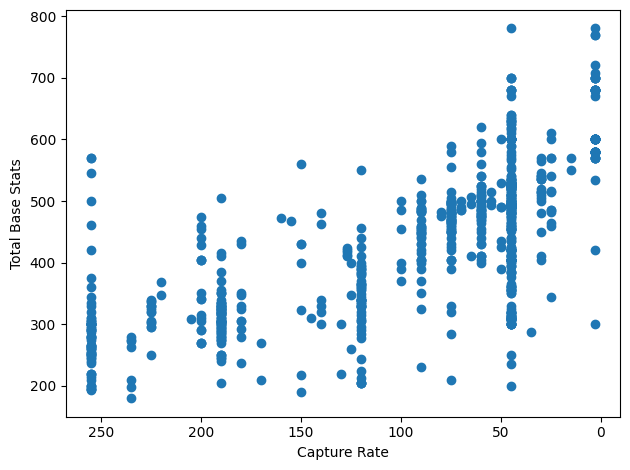


Pearson correlation coefficient: -0.709


In [23]:
df_plot = df.copy()

df_plot["capture_rate"] = (
    df_plot["capture_rate"]
    .astype(str)
    .str.findall(r"\d+")
)

df_plot = df_plot.explode("capture_rate")

df_plot = df_plot.dropna(subset=["capture_rate"])

df_plot["capture_rate"] = df_plot["capture_rate"].astype(int)

plt.scatter(df_plot["capture_rate"], df_plot["base_total"])
plt.xlabel("Capture Rate")
plt.ylabel("Total Base Stats")
plt.gca().invert_xaxis()

plt.tight_layout()
plt.show()

correlation = df["base_total"].corr(df_plot["capture_rate"])
print(f"\nPearson correlation coefficient: {correlation:.3f}")

We can easily observe that the lower the capture rate, the higher the Total Base Stats. Although there are many exceptions, this is the general trend for most Pokémon, and it is strongly reflected in the correlation coefficient.

## How do Pokémon Stats Relate to Each Other?

In this section, we propose to find out whether any stats are specially compatible/incompatible with others, answering questions as:

> Do defensive/offensive Pokémon exist?

or

> Are there physical/special Pokémon?


Before analyzing how stats relate to each other, we normalized the dataset to measure the proportion of total stat points each Pokémon allocates to every stat.

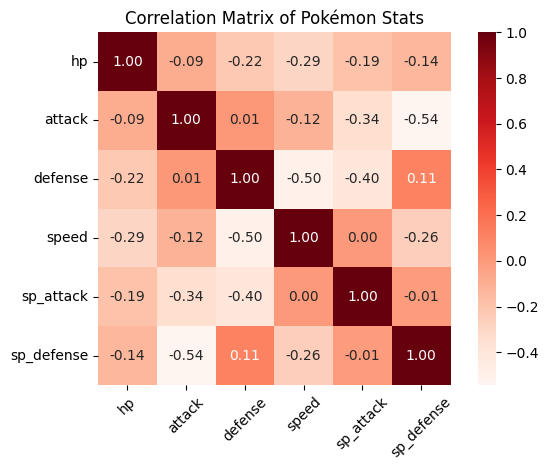

In [24]:
stats_cols = ["hp", "attack", "defense", "speed", "sp_attack", "sp_defense"]

df_norm = df[stats_cols].div(df["base_total"], axis=0)
corr_norm = df_norm.corr()

plt.figure()
sns.heatmap(
    corr_norm,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    square=True
)

plt.title("Correlation Matrix of Pokémon Stats")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

This heatmap helps us visualize **trade-offs** — showing which stats tend to compete with each other, which ones are relatively independent, and which occasionally grow together.


Because each Pokémon distributes a fixed total of points, increasing investment in one stat usually reduces the relative allocation available for others. This explains the general **tendency toward negative correlations** in the graph.

Below is a contextual interpretation of the correlation ranges:

#### **-0.60 to -0.30 — Strong Trade-Off**
These stats strongly compete for the same budget. Pokémon rarely invest heavily in both.

*Example: Speed and Defense.*

#### **-0.30 to -0.15 — Moderate Trade-Off**
These stats tend to compete, though less rigidly. They are somewhat incompatible.

*Example: Speed and HP.*

#### **-0.15 to -0.05 — Mild Trade-Off**
A common structural trade-off due to the fixed stat budget. When one increases, the other slightly decreases.

*Example: HP and Special Defense.*

#### **-0.05 to 0.05 — Independent**
No systematic trade-off. Investment in one does not meaningfully affect the other.

*Example: HP and Special Defense.*

#### **0.05 to 0.20 — Allied**
These are positively related. If one is high, the other one slightly tends to increase.

*Example, Defense and Special Defense.*

### What insight can we get from this?

We can learn a lot about Pokémon design from this correlations, specially looking at the most extreme values. So, let's identify some new types with our data.

#### Defensive Pokémon

Defensive stats are the most positively correlated:

*  Defense - Special Defense (0.11).

Also the defense stat is highly related to strong Trade-Offs that affect very negatively their offensive stats:
*  Defense - Special Attack (-0.40)
*  Defense - Speed (-0.50)

The combination of high deffensive stats with really weak offensive ones, leads to a Pokémon with great resistance and poor offensive power.

#### Offensive Pokémon

The offensive stats do not get on well:
*  Attack - Special Attack (-0.34)

However, both combine better with Speed:
*  Attack - Speed (-0.12)
*  Special Attack - Speed (0.00)

There isn't enough evidence to conceive a purely offensive Pokémon, but we find that speed and offensive stats do not compete.

#### Physical Pokémon

Many basic stats have independent correlations:

+  HP - Attack (-0.09)
+  Attack - Defense (0.01)

As attack is highly negatively correlated with special stats:

+ Attack - Special Defense (-0.54)
+ Attack - Special Attack (-0.34)

We can suppose some Pokémon specialize on Basic Attack, while others focus on Special Attack (Physical vs Special).

#### Special Pokémon
Special stats do not compete:
+ Special Attack - Special Defense (-0.01)

However, Attack and Special Attack are highly competitive
+ Attack - Special Attack (-0.34)

Despite not existing a tendency towards high special stats alltogether, the negative correlation between Attack and Special Attack suggests each Pokémon "chooses" primarily one of these offensive stats/styles.



